**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppresses all warning messages

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.utils.class_weight import compute_class_weight

**Load Dataset**

In [360]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Explore Dataset**

In [361]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age             

**Separate Features and Labels**

In [362]:
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

**Train-Test Split**

In [363]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Validation Split**

In [364]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)


**Feature Scaling**

In [365]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_val = scaler.transform(X_val)

**Class Weight**

In [366]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

**Build Neural Network**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduling = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../model/diabetes_model.keras",
    monitor="val_loss",
    save_best_only=True
)


**Compile Model**

In [368]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
    'accuracy',
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.Precision(),
    tf.keras.metrics.Recall()
]
)

**Train Model**

In [369]:
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    epochs=100, 
    batch_size=32,
    callbacks=[early_stopping, lr_scheduling, checkpoint]
    
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5336 - auc: 0.5622 - loss: 0.8064 - precision_20: 0.3867 - recall_20: 0.5789 - val_accuracy: 0.6829 - val_auc: 0.7983 - val_loss: 0.6518 - val_precision_20: 0.5303 - val_recall_20: 0.8140 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6436 - auc: 0.7156 - loss: 0.6323 - precision_20: 0.4923 - recall_20: 0.7485 - val_accuracy: 0.6748 - val_auc: 0.8584 - val_loss: 0.6308 - val_precision_20: 0.5205 - val_recall_20: 0.8837 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6619 - auc: 0.7446 - loss: 0.5975 - precision_20: 0.5094 - recall_20: 0.7895 - val_accuracy: 0.7154 - val_auc: 0.8788 - val_loss: 0.6142 - val_precision_20: 0.5556 - val_recall_20: 0.9302 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6619 - auc: 0.7851 - loss: 0.5655 - precision_20: 0.5097 - recall_20: 0.7719 - val_accuracy: 0.7236 

**Evaluate**

In [370]:
loss, accuracy, auc, precision, recall = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)
print("AUC:", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6948 - auc: 0.8215 - loss: 0.5393 - precision_20: 0.5443 - recall_20: 0.7963
Accuracy: 0.6948052048683167
AUC: 0.821481466293335


**Predictions**

In [371]:
pred = model.predict(X_test)

pred = (
    pred > 0.55
).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


**Classification Report**

In [372]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.70      0.77       100
           1       0.58      0.76      0.66        54

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154



**Confusion Matrix**

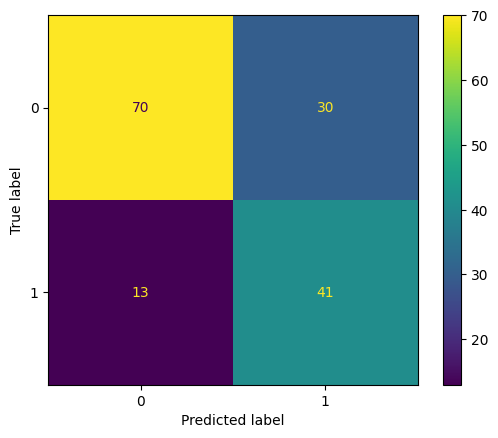

In [373]:
cm = confusion_matrix(
    y_test,
    pred
)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**Plot Training Curves**

Accuracy

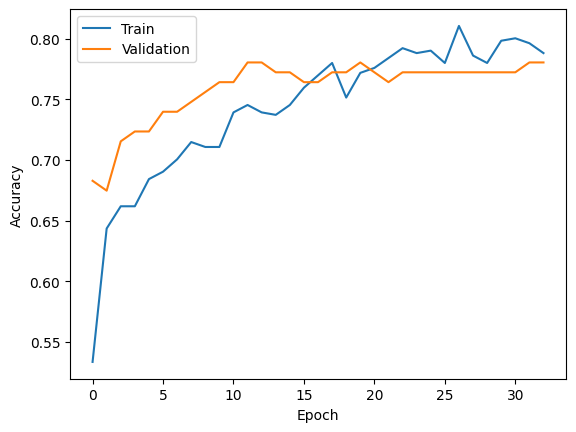

In [374]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.ylabel('Accuracy')      
plt.xlabel('Epoch') 

plt.legend([
    'Train',
    'Validation'
])

plt.show()

AUC

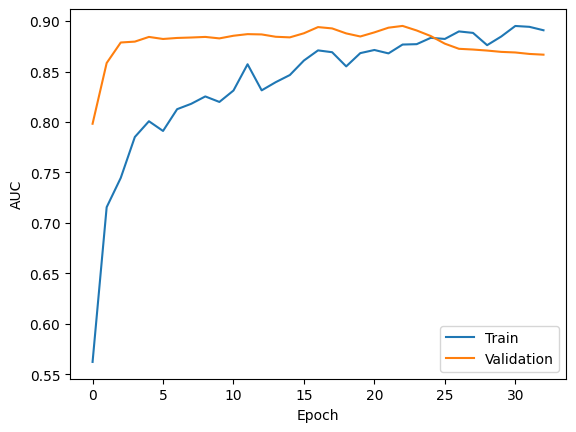

In [375]:
plt.plot(
    history.history['auc']
)

plt.plot(
    history.history['val_auc']
)

plt.ylabel('AUC')       
plt.xlabel('Epoch')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

Loss

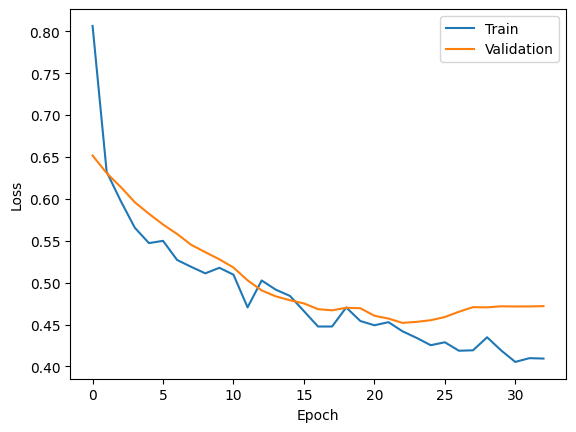

In [376]:
plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.ylabel('Loss')        
plt.xlabel('Epoch')

plt.legend([
    'Train',
    'Validation'
])

plt.show()